In [7]:
from google.colab import files

# Subir el archivo desde tu PC a Google Colab
uploaded = files.upload()
!kaggle datasets download -d hammadfarooq470/world-suicide-mortality-data-2000-2021

Saving world_suicide_rates.csv to world_suicide_rates.csv
Dataset URL: https://www.kaggle.com/datasets/hammadfarooq470/world-suicide-mortality-data-2000-2021
License(s): MIT
world-suicide-mortality-data-2000-2021.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
import pandas as pd

# Usar punto y coma como delimitador
df = pd.read_csv("world_suicide_rates.csv", delimiter=',', encoding='utf-8')

# Si encuentras errores de delimitador, intenta también con el punto y coma
df = pd.read_csv("world_suicide_rates.csv", delimiter=';', encoding='utf-8')
df.head()

,"Country Name,Country Code,Year,Suicide Rate"
0,"Afghanistan,AFG,2000,4.36"
1,"Afghanistan,AFG,2001,4.38"
2,"Afghanistan,AFG,2002,4.26"
3,"Afghanistan,AFG,2003,4.24"
4,"Afghanistan,AFG,2004,4.23"


In [16]:
# Revisar los valores faltantes en cada columna
missing_values = df.isnull().sum()  # Contamos los valores nulos en cada columna

# Cuantificar la magnitud del problema
total_missing = missing_values.sum()  # Total de valores faltantes
total_cells = df.size  # Total de celdas en el DataFrame
missing_percentage = (total_missing / total_cells) * 100  # Porcentaje de valores faltantes

# Mostrar el resumen
print(f"Total valores faltantes: {total_missing} de {total_cells} celdas ({missing_percentage:.2f}%)")
print("\nValores faltantes por columna:")
print(missing_values)

# Separar columnas numéricas y no numéricas
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
non_numeric_columns = df.select_dtypes(exclude=['float64', 'int64']).columns

# Imputar las columnas numéricas con la media
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Para las columnas no numéricas, podemos imputarlas con la moda (valor más frecuente)
df[non_numeric_columns] = df[non_numeric_columns].fillna(df[non_numeric_columns].mode().iloc[0])

# Mostrar las primeras filas del DataFrame después de imputar los valores faltantes
df.head()

Total valores faltantes: 0 de 5126 celdas (0.00%)

Valores faltantes por columna:
Country Name,Country Code,Year,Suicide Rate    0
dtype: int64


,"Country Name,Country Code,Year,Suicide Rate"
0,"Afghanistan,AFG,2000,4.36"
1,"Afghanistan,AFG,2001,4.38"
2,"Afghanistan,AFG,2002,4.26"
3,"Afghanistan,AFG,2003,4.24"
4,"Afghanistan,AFG,2004,4.23"


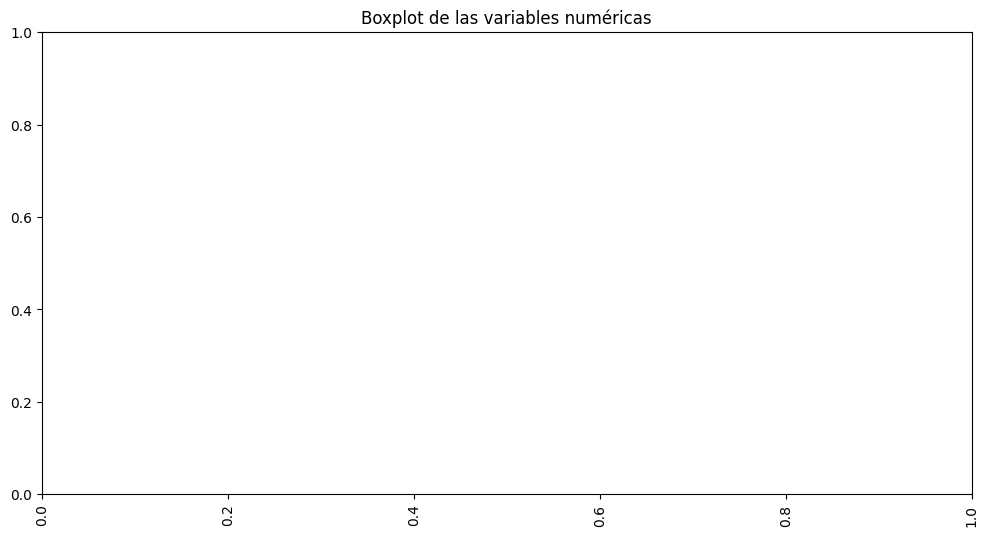

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un boxplot para todas las columnas numéricas
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot de las variables numéricas")
plt.xticks(rotation=90)  # Girar etiquetas si es necesario
plt.show()

In [20]:
from scipy.stats import zscore

# Calcular el Z-score para cada valor en el dataset (solo para variables numéricas)
z_scores = zscore(df.select_dtypes(include=['float64', 'int64']))

# Filtrar los valores con Z-score mayor a 3 o menor a -3 (outliers)
outliers_z = (z_scores > 3) | (z_scores < -3)

# Mostrar el número de outliers por columna
print("\nNúmero de outliers por columna (usando Z-score):")
print(outliers_z.sum())


Número de outliers por columna (usando Z-score):
0


In [ ]:
df_cleaned = df[~outliers_IQR.any(axis=1)]  # Eliminar filas con outliers usando IQR

In [ ]:
df_adjusted = df.copy()
df_adjusted[outliers_IQR] = df_adjusted[outliers_IQR].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)